In [59]:
# Testing --> Tesing AND validation
# Onehot-Encode
# DataLoader support

In [ ]:
from augment import train_transform,test_transform

train_transform

Compose(
    ToPILImage()
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    [RandomRotation(degrees=[-180.0, 180.0], interpolation=nearest, expand=False, fill=0), RandomHorizontalFlip(p=0.5), RandomVerticalFlip(p=0.5)]
    ToTensor()
)

In [60]:
from torchvision import transforms
train_transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize((224,224)),
                # transforms.RandomRotation(180),
                # transforms.RandomHorizontalFlip(p=0.5),
                # transforms.RandomVerticalFlip(p=0.5),
                # transforms.ColorJitter(hue=0,saturation=0,brightness=0.2,contrast=0.2),
                # transforms.GaussianBlur(kernel_size=(3,3)),
                transforms.ToTensor(),
                # transforms.RandomErasing(p=0.25,scale=(0.05,0.15)),
                ])

test_transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize((224,224)),
                transforms.ToTensor()
                ])

In [108]:
import numpy as np
import torch
from torch.utils.data import Dataset,random_split
from torchvision.io import read_image
from torchvision.transforms import v2
from sklearn.preprocessing import LabelEncoder
import os
import glob
from tqdm.auto import tqdm

class LoadBRISC():
    def __init__(self):
        self.cls_root = './brisc2025/classification_task'
        self.seg_root = './brisc2025/segmentation_task'
    
    def load(self,classes:str='all',planes:str='all',label_type:str='class',encoding_type='integer',split_val=True,train_transform=None,test_transform=None,generator=None):
        '''
        Loads BRISC 2025 dataset into a PyTorch Dataset.

        Args:
            classes (str, default='all'): Classes to pick.
                Supported values are:
                    - 'all' : Picks all classes
                    - 'tumor' : Picks all classes except 'no_tumor' 
            planes (str: default='all') : Planes to pick
                Supported values are:
                    - 'all' : Picks all planes
                    - 'ax' : Axial plane
                    - 'sa' : Sagital plane
                    - 'co' : Coronal plane
            label_type (str, default='class'): Label return type
                Supported values are:
                    - 'class' : Returns tumor types as labels
                    - 'plane' : Returns plane types as labels
                    - 'both' : Returns tumor and plane types as labels
            encoding_type (str, default='integer'): Label encoding type
                Supported values are:
                    - 'onehot' : Returns labels in onehot encoding
                    - 'integer' : Returns labels in integer labels
            split_val (bool, default==True): Whether to split the test data into test and validation set or not
            train_transform (torchvision.transforms): Image transformation for the training dataset
            test_transform (torchvision.transforms): Image transformation for the testing dataset
            generator (torch.Generator): PyTorch generator for reproducability

        Returns:
            PyTorch Dataset object of selected configuration.
        '''
        if classes not in ['all','tumor']:
            raise ValueError('Unknown value for "classes" arguement! Use "all" or "tumor".')
        if planes not in ['all','ax','sa','co']:
            raise ValueError('Unknown value for "planes" arguement! Use "all", "ax", "sa", or "co".')
        if label_type not in ['class','plane','both']:
            raise ValueError('Unknown value for "label_type" arguement! Use "class", "plane", or "both".')
        if encoding_type not in ['onehot','integer']:
            raise ValueError('Unknown value for "encoding_type" arguement! Use "integer", or "onehot".')

        self.classes_abr = {
            'gl':'glioma',
            'me':'meningioma',
            'pi':'pituitary',
            'no':'no_tumor'
        }
        self.classes_dict = {
            'all':['gl','me','no','pi'],
            'tumor':['gl','me','pi']
        }
        self.planes_dict = {
            'all':['ax','sa','co'],
            'ax':['ax'],
            'sa':['sa'],
            'co':['co']
        }
        self.classes = self.classes_dict[classes]
        self.planes = self.planes_dict[planes]
        self.encoding_type = encoding_type
        self.split_val = split_val
        if generator:
            self.generator = generator

        # Get image id and labels
        train_ids = []
        test_ids = []
        train_labels = []
        test_labels = []
        for cls in self.classes:
            for pln in self.planes:
                labels = f'{cls}' if label_type == 'class' else f'{pln}' if label_type == 'plane' else f'{cls} {pln}'
                if cls == 'no':
                    train_img_path = sorted(glob.glob(os.path.join(self.cls_root,'train','no_tumor',f'*{pln}*')))
                    test_img_path = sorted(glob.glob(os.path.join(self.cls_root,'test','no_tumor',f'*{pln}*')))

                    train_id = [path.split('/')[-1].replace('brisc2025_train_','').split('.')[0] for path in train_img_path] 
                    test_id = [path.split('/')[-1].replace('brisc2025_test_','').split('.')[0] for path in test_img_path]
                   
                    train_ids.extend(train_id)
                    test_ids.extend(test_id)
                else:
                    train_img_path = sorted(glob.glob(os.path.join(self.seg_root,'train','images',f'*{cls}_{pln}*')))
                    test_img_path = sorted(glob.glob(os.path.join(self.seg_root,'test','images',f'*{cls}_{pln}*')))

                    train_id = [path.split('/')[-1].replace('brisc2025_train_','').split('.')[0] for path in train_img_path] 
                    test_id = [path.split('/')[-1].replace('brisc2025_test_','').split('.')[0] for path in test_img_path] 

                    train_ids.extend(train_id)
                    test_ids.extend(test_id)
                train_labels.extend([labels for i in range(len(train_img_path))])
                test_labels.extend([labels for i in range(len(test_img_path))])

        # Get images and masks
        train_imgs,train_masks = self.__import_image(train_ids,'train')
        test_imgs,test_masks = self.__import_image(test_ids,'test')
        train_labels = np.array(train_labels)
        test_labels = np.array(test_labels)

        # Encode labels
        train_labels = self.__encode_label(train_labels)
        test_labels = self.__encode_label(test_labels)

        # Put images and masks into a Dataset object
        self.train_ds = DatasetClass(train_imgs,train_masks,train_labels,transform=train_transform)
        self.test_ds = DatasetClass(test_imgs,test_masks,test_labels,transform=test_transform)
        if self.split_val:
            self.val_ds,self.test_ds = random_split(self.test_ds,[0.5,0.5],generator=self.generator)
            return self.train_ds,self.val_ds,self.test_ds
        else:
            return self.train_ds,self.test_ds

    def __encode_label(self,labels:np.ndarray):
        '''
        Encodes labels into integer or onehot encoding
        Args:
            labels (np.ndarray): Array of labels to encode
        Returns:
            Array of encoded labels
        '''
        encoder = LabelEncoder()
        labels_enc = encoder.fit_transform(labels)
        self.classes = [self.classes_abr[cls] for cls in list(encoder.classes_)]
        if self.encoding_type == 'onehot':
            labels_enc = np.eye(len(self.classes),dtype=int)[labels_enc]
        return labels_enc

    def __import_image(self,ids,mode):
        '''
        Imports images and masks from given list of paths
        Args:
            ids (list): List of image ids
            mode (str) : "train" or "test" set
        Returns:
            PyTorch tensor of the images and masks in one batch
        '''
        imgs,masks = [],[]
        for id in tqdm(ids):
            cls = self.classes_abr[id.split('_')[1]]
            # img_path = glob.glob(os.path.join(self.cls_root,f'{mode}/{cls}/*{id}*'))[0]
            img_path = os.path.join(self.cls_root,f'{mode}/{cls}/brisc2025_{mode}_{id}.jpg')
            img = read_image(img_path)
            img = v2.functional.resize(img,(224,224))
            img = v2.Grayscale(num_output_channels=1)(img)
            if cls == 'no_tumor':
                mask = torch.zeros_like(img)
            else:
                # mask_path = glob.glob(os.path.join(self.seg_root,f'{mode}/masks/*{id}*'))[0]
                mask_path = os.path.join(self.seg_root,f'{mode}/masks/brisc2025_{mode}_{id}.png')
                mask = read_image(mask_path)
                mask = v2.functional.resize(mask,(224,224))
                mask = (mask >= 0.7)
            imgs.append(img)
            masks.append(mask)
        imgs = torch.cat(imgs).to(torch.float32).unsqueeze(1)
        masks = torch.cat(masks).to(torch.float32).unsqueeze(1)
        return imgs,masks

class DatasetClass(Dataset):
    def __init__(self,imgs,masks,labels,transform=None):
        self.imgs = imgs
        self.masks = masks
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return self.imgs.shape[0]

    def __getitem__(self, index):
        img = self.imgs[index]
        mask = self.masks[index]
        label = self.labels[index]

        if self.transform:
            img = self.transform(img)

        return img,mask,label

In [109]:
import torch
generator = torch.Generator().manual_seed(42)

loader = LoadBRISC()
train_ds,val_ds,test_ds = loader.load(classes='tumor',planes='all',encoding_type='onehot',split_val=True,generator=generator)

  0%|          | 0/3933 [00:00<?, ?it/s]

  0%|          | 0/860 [00:00<?, ?it/s]

In [63]:
from torch.utils.data import DataLoader

train_dl = DataLoader(train_ds,
                      batch_size=16,
                      shuffle=True,
                      drop_last=True)
val_dl = DataLoader(val_ds,
                    batch_size=16,
                    shuffle=False,
                    drop_last=True)
test_dl = DataLoader(test_ds,
                     batch_size=16,
                     shuffle=False,
                     drop_last=False)

In [64]:
import torch
from torch import nn
from torchvision import models

class CAM(nn.Module):
    def __init__(self,num_class,backbone='vgg'):
        super().__init__()
        if backbone == 'vgg':
            self.pretrain = models.vgg19_bn(weights=models.VGG19_BN_Weights.IMAGENET1K_V1)
            self.backbone = nn.Sequential(*list(self.pretrain.features.children())[:-13])
            del self.pretrain.avgpool
            del self.pretrain.classifier
        elif backbone == 'resnet':
            self.pretrain = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
            self.backbone = nn.Sequential(*list(models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1).children())[:-3])
            del self.pretrain.avgpool
            del self.pretrain.fc
        elif backbone == 'effnet':
            self.pretrain = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
            self.backbone = nn.Sequential(*list(list(models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1).children())[0].children())[:6])
            del self.pretrain.avgpool
            del self.pretrain.classifier
        else:
            raise ValueError('Unknown backbone! Use "vgg", "resnet", or "effnet".')
        
        dummy_input = torch.zeros(1, 3, 224, 224)
        with torch.no_grad():
            dummy_output = self.backbone(dummy_input)
        fmaps_count = dummy_output.shape[1]
        
        self.classifier  = nn.Sequential(
            nn.Conv2d(fmaps_count,128,kernel_size=3,stride=1,padding=1),
            nn.BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True),
            nn.ReLU(),
            nn.Conv2d(128,128,kernel_size=3,stride=1,padding=1),
            nn.BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True),
            nn.ReLU(),
            nn.Conv2d(128,num_class,kernel_size=1,stride=1,padding=0)
        )
        self.gap = nn.AdaptiveAvgPool2d(output_size=(1,1))
    
    def forward(self,x):
        x = x.expand(-1,3,-1,-1)
        fmaps = self.backbone(x)
        fmaps_cls = self.classifier(fmaps)
        logits = self.gap(fmaps_cls).squeeze()
        preds = torch.argmax(logits,dim=1)

        self.cams = self.cam_to_mask(fmaps_cls,preds)
        return logits
    
    def cam_to_mask(self,cams,preds,threshold=0.7):
        cams = torch.relu(cams)
        cams = cams[np.arange(cams.shape[0]),preds,:,:]
        cams_min = cams.min(dim=-1)[0].min(dim=-1)[0].unsqueeze(-1).unsqueeze(-1)
        cams_max = cams.max(dim=-1)[0].max(dim=-1)[0].unsqueeze(-1).unsqueeze(-1)

        norm_cam = ((cams-cams_min)/(cams_max-cams_min+1e-8)).unsqueeze(1)
        norm_cam = torch.nn.functional.interpolate(norm_cam,(224,224),mode='bilinear')
        
        preds_masks = norm_cam >= threshold
        return preds_masks

In [65]:
model = CAM(3,backbone='effnet')
# model.backbone

In [97]:
import torch
from torch import nn
from tqdm.auto import tqdm
from torchmetrics.functional.segmentation import dice_score
from torchmetrics.detection.iou import IntersectionOverUnion
from torchvision.ops import masks_to_boxes
from sklearn.metrics import accuracy_score,confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = 'cuda' if torch.cuda.is_available() else 'cpu'

def train_step(model,criterion,optimizer,dataloader,device=device):
    model.to(device)
    model.train()
    losses, accs, dscs = 0,0,0
    for batch,(X,M,y) in enumerate(dataloader):
        X,M,y = X.to(device),M.to(device),y.to(device)
        y_logit = model(X)
        y_mask = model.cams
        y = y.to(torch.float32)
        y_pred = torch.softmax(y_logit,1)
        
        loss = criterion(y_logit,y)
        losses += loss
        accs += accuracy_score(y.argmax(1).cpu(),y_pred.argmax(1).cpu().detach())
        
        dscs += dice_score(y_mask.long().cpu(),M.long().cpu(),num_classes=2,input_format='index',average='macro',include_background=False).mean().item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    losses /= len(dataloader)
    losses = losses.cpu().detach().item()
    accs /= len(dataloader)
    dscs /= len(dataloader)
    return losses,accs,dscs

def val_step(model,criterion,dataloader,device=device,return_data=False):
    model.to(device)
    model.eval()
    losses, accs, dscs = 0,0,0
    if return_data:
        Xs = []
        ys = []
        y_preds = []
        Ms = []
        cams = []
    with torch.inference_mode():
        for batch,(X,M,y) in enumerate(dataloader):
            X,M,y = X.to(device),M.to(device),y.to(device)
            y_logit = model(X)
            y_mask = model.cams
            y = y.to(torch.float32)
            y_pred = torch.softmax(y_logit,1)

            losses += criterion(y_logit,y).cpu().detach().item()
            accs += accuracy_score(y.argmax(1).cpu(),y_pred.argmax(1).cpu().detach())
            dscs += dice_score(y_mask.long().cpu(),M.long().cpu(),num_classes=2,input_format='index',average='macro',include_background=False).mean().item()

            if return_data:
                Xs.extend(X.cpu())
                ys.extend(y.argmax(1).cpu())
                y_preds.extend(y_pred.argmax(1).cpu())
                Ms.extend(M.cpu())
                cams.extend(y_mask.cpu())
        losses /= len(dataloader)
        accs /= len(dataloader)
        dscs /= len(dataloader)
    if return_data:
        Xs = torch.cat(Xs,dim=0)
        ys = torch.stack(ys)
        y_preds = torch.stack(y_preds)
        Ms = torch.cat(Ms,dim=0).to(torch.long)
        cams = torch.cat(cams,dim=0)
        return (losses,accs,dscs),(Xs,ys,y_preds,Ms,cams)
    else:
        return losses,accs,dscs

def train_loop(model,epochs,criterion,optimizer,device,train_dataloader,val_dataloader,scheduler=None):
    '''
    Function to train CAM model
    Args:
        model (torch.nn.Module): The CAM model
            Requirement of the model:
                - Must split into images, masks, and labels
                - Must have .cams attribute that returns the cam of each item in the batch
                - Must be onehot encoded multiclass problem
        epochs (int): The number of epochs to train the model for
        criterion (torch.nn.Module): Loss function for the classification task
        optimizer (torch.optim): Optimizer function
        device (str): Device to compute calculations on
        train_dataloader (DataLoader): PyTorch DataLoader object containing the train data
        test_dataloader (DataLoader): PyTorch DataLoader object containing the test data
        scheduler (torch.optim.lr_scheduler): Scheduler object to alter learning rate mid-training
    Returns:
        A dictionary containing the loss, accuracy, and dice similarity coefficients at each epoch for both train and validation
    '''
    metrics = {'train_loss':[],
               'train_acc':[],
               'train_dsc':[],
               'val_loss':[],
               'val_acc':[],
               'val_dsc':[]}

    for epoch in tqdm(range(epochs)):
        print(f'Epoch {epoch}:')
        train_loss,train_acc,train_dsc = train_step(model,criterion,optimizer,train_dataloader,device)
        val_loss,val_acc,val_dsc = val_step(model,criterion,val_dataloader,device,return_data=False)

        if scheduler:
            scheduler.step(val_loss)
            
        metrics['train_loss'].append(train_loss)
        metrics['train_acc'].append(train_acc)
        metrics['train_dsc'].append(train_dsc)
        metrics['val_loss'].append(val_loss)
        metrics['val_acc'].append(val_acc)
        metrics['val_dsc'].append(val_dsc)
        print(f'Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.2f} | Train DSC: {train_dsc:.2f} | Val Loss: {val_loss:.3f} | Val Acc: {val_acc:.2f} | Val DSC: {val_dsc:.2f}')
    return metrics

def evaluate(model,test_dataloader,criterion=nn.CrossEntropyLoss()):
    _, preds = val_step(model,criterion,test_dataloader,device=device,return_data=True)
    Xs,ys,y_preds,Ms,cams = preds
    # Accuracy
    acc = accuracy_score(ys,y_preds)
    # Dice Similarity Coef.
    dsc = dice_score(cams,Ms,num_classes=2).median()
    # IoU (n = number of target PER IMAGE)
    cam_bbox = [{
        'boxes': masks_to_boxes(cams[i].unsqueeze(0)), # nhw --> xyxy
        'labels': y_preds[i].unsqueeze(0) # n
    } for i in range(Xs.shape[0])]
    M_bbox = [{
        'boxes': masks_to_boxes(Ms[i].unsqueeze(0)), # nhw --> xyxy
        'labels': ys[i].unsqueeze(0) # n 
    } for i in range(Xs.shape[0])]
    iou = IntersectionOverUnion()(cam_bbox,M_bbox)['iou']

    results = {
        'metrics':(acc,dsc,iou),
        'data':(Xs,ys,y_preds,Ms,cams),
        'bbox':(M_bbox,cam_bbox)
    }
    return results

def plot_confmat(ys,y_preds,classes=None):
    confmat = confusion_matrix(ys,y_preds)
    classes = classes if classes else [i for i in range(len(np.unique(ys)))]
    sns.heatmap(confmat,annot=True,fmt='d',cmap='viridis',xticklabels=classes,yticklabels=classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

def plot_sample(Xs,Ms,cams,index=None):
    if index is None:
        index = np.random.randint(Xs.shape[0])
    
    plt.figure(figsize=(10,4))
    plt.subplot(1,3,1)
    plt.imshow(Xs[index].squeeze().cpu())
    plt.axis(False)
    plt.title('Image')

    M = (Ms[index].squeeze().cpu() >= 0.5).long()
    plt.subplot(1,3,2)
    plt.imshow(M)
    plt.axis(False)
    plt.title('GT Mask')

    cam = (cams[index].squeeze().cpu() >= 0.5).long()
    plt.subplot(1,3,3)
    plt.imshow(cam)
    plt.axis(False)
    plt.title('CAM')

    plt.suptitle(f'DSC = {dice_score(cam.unsqueeze(0),M.unsqueeze(0),num_classes=2,include_background=False,average='macro',input_format='index').item():.2f}',y=0.9)

def plot_history(epochs,history):
    plt.subplot(1,3,1)
    sns.lineplot(x=np.arange(epochs),y=history['train_loss'],marker='o')
    sns.lineplot(x=np.arange(epochs),y=history['val_loss'],marker='o')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')

    plt.subplot(1,3,2)
    sns.lineplot(x=np.arange(epochs),y=history['train_acc'],marker='o')
    sns.lineplot(x=np.arange(epochs),y=history['val_acc'],marker='o')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')

    plt.subplot(1,3,3)
    sns.lineplot(x=np.arange(epochs),y=history['train_dsc'],marker='o',label='Train')
    sns.lineplot(x=np.arange(epochs),y=history['val_dsc'],marker='o',label='Val')
    plt.legend(loc='center right',bbox_to_anchor=(1.26,0.5))
    plt.title('DSC')
    plt.xlabel('Epochs')
    plt.ylabel('DSC')
    plt.suptitle('Training History Curve')
    plt.tight_layout()

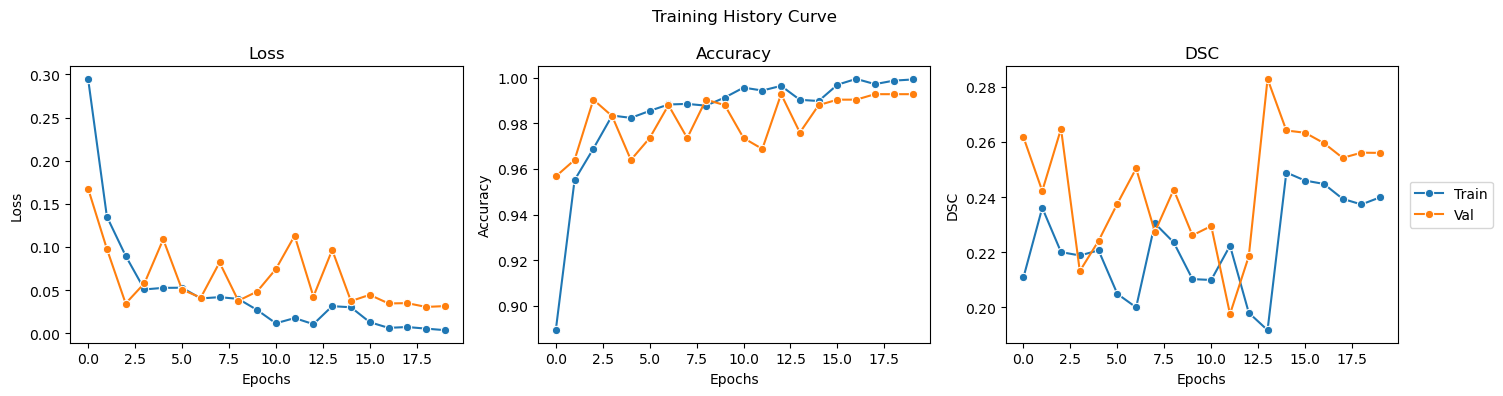

In [98]:
plt.figure(figsize=(15,4))
plot_history(EPOCHS,history_effnet)
plt.show()

In [67]:
os.makedirs('saves',exist_ok=True)

In [68]:
MODEL_EFFNET= CAM(len(loader.classes),backbone='effnet')
EPOCHS = 20
LR = 1e-3
WD = 1e-4
CRITERION = nn.CrossEntropyLoss()
OPTIMIZER = torch.optim.AdamW(MODEL_EFFNET.parameters(),lr=LR,weight_decay=WD)
SCHEDULER = torch.optim.lr_scheduler.ReduceLROnPlateau(OPTIMIZER, mode='min', factor=0.1, patience=10)
history_effnet = train_loop(MODEL_EFFNET,EPOCHS,CRITERION,OPTIMIZER,device,train_dl,val_dl,SCHEDULER)
torch.save(MODEL_EFFNET.state_dict(),'saves/cam_effnet_3.pth')

MODEL_EFFNET.load_state_dict(torch.load('saves/cam_effnet_3.pth'))

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 0:
Train Loss: 0.295 | Train Acc: 0.89 | Train DSC: 0.21 | Val Loss: 0.168 | Val Acc: 0.96 | Val DSC: 0.26
Epoch 1:
Train Loss: 0.135 | Train Acc: 0.96 | Train DSC: 0.24 | Val Loss: 0.098 | Val Acc: 0.96 | Val DSC: 0.24
Epoch 2:
Train Loss: 0.090 | Train Acc: 0.97 | Train DSC: 0.22 | Val Loss: 0.034 | Val Acc: 0.99 | Val DSC: 0.26
Epoch 3:
Train Loss: 0.051 | Train Acc: 0.98 | Train DSC: 0.22 | Val Loss: 0.058 | Val Acc: 0.98 | Val DSC: 0.21
Epoch 4:
Train Loss: 0.053 | Train Acc: 0.98 | Train DSC: 0.22 | Val Loss: 0.109 | Val Acc: 0.96 | Val DSC: 0.22
Epoch 5:
Train Loss: 0.053 | Train Acc: 0.99 | Train DSC: 0.20 | Val Loss: 0.051 | Val Acc: 0.97 | Val DSC: 0.24
Epoch 6:
Train Loss: 0.040 | Train Acc: 0.99 | Train DSC: 0.20 | Val Loss: 0.041 | Val Acc: 0.99 | Val DSC: 0.25
Epoch 7:
Train Loss: 0.042 | Train Acc: 0.99 | Train DSC: 0.23 | Val Loss: 0.082 | Val Acc: 0.97 | Val DSC: 0.23
Epoch 8:
Train Loss: 0.040 | Train Acc: 0.99 | Train DSC: 0.22 | Val Loss: 0.038 | Val Acc: 0.99

<All keys matched successfully>

In [69]:
MODEL_VGG= CAM(len(loader.classes),backbone='vgg')
EPOCHS = 20
LR = 1e-3
WD = 1e-4
CRITERION = nn.CrossEntropyLoss()
OPTIMIZER = torch.optim.AdamW(MODEL_VGG.parameters(),lr=LR,weight_decay=WD)
SCHEDULER = torch.optim.lr_scheduler.ReduceLROnPlateau(OPTIMIZER, mode='min', factor=0.1, patience=10)
history_vgg = train_loop(MODEL_VGG,EPOCHS,CRITERION,OPTIMIZER,device,train_dl,val_dl,SCHEDULER)
torch.save(MODEL_VGG.state_dict(),'saves/cam_vgg_3.pth')

MODEL_VGG.load_state_dict(torch.load('saves/cam_vgg_3.pth'))

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 0:
Train Loss: 0.416 | Train Acc: 0.84 | Train DSC: 0.13 | Val Loss: 1.808 | Val Acc: 0.58 | Val DSC: 0.09
Epoch 1:
Train Loss: 0.280 | Train Acc: 0.89 | Train DSC: 0.17 | Val Loss: 1.199 | Val Acc: 0.58 | Val DSC: 0.14
Epoch 2:
Train Loss: 0.185 | Train Acc: 0.93 | Train DSC: 0.16 | Val Loss: 1.341 | Val Acc: 0.69 | Val DSC: 0.10
Epoch 3:
Train Loss: 0.166 | Train Acc: 0.94 | Train DSC: 0.15 | Val Loss: 0.403 | Val Acc: 0.84 | Val DSC: 0.14
Epoch 4:
Train Loss: 0.147 | Train Acc: 0.95 | Train DSC: 0.16 | Val Loss: 0.188 | Val Acc: 0.93 | Val DSC: 0.15
Epoch 5:
Train Loss: 0.107 | Train Acc: 0.97 | Train DSC: 0.15 | Val Loss: 0.218 | Val Acc: 0.91 | Val DSC: 0.17
Epoch 6:
Train Loss: 0.094 | Train Acc: 0.97 | Train DSC: 0.15 | Val Loss: 0.373 | Val Acc: 0.87 | Val DSC: 0.10
Epoch 7:
Train Loss: 0.101 | Train Acc: 0.96 | Train DSC: 0.14 | Val Loss: 0.313 | Val Acc: 0.88 | Val DSC: 0.12
Epoch 8:
Train Loss: 0.076 | Train Acc: 0.97 | Train DSC: 0.14 | Val Loss: 1.162 | Val Acc: 0.75

<All keys matched successfully>

In [70]:
MODEL_RESNET= CAM(len(loader.classes),backbone='resnet')
EPOCHS = 20
LR = 1e-3
WD = 1e-4
CRITERION = nn.CrossEntropyLoss()
OPTIMIZER = torch.optim.AdamW(MODEL_RESNET.parameters(),lr=LR,weight_decay=WD)
SCHEDULER = torch.optim.lr_scheduler.ReduceLROnPlateau(OPTIMIZER, mode='min', factor=0.1, patience=10)
history_resnet = train_loop(MODEL_RESNET,EPOCHS,CRITERION,OPTIMIZER,device,train_dl,val_dl,SCHEDULER)
torch.save(MODEL_RESNET.state_dict(),'saves/cam_resnet_3.pth')

MODEL_RESNET.load_state_dict(torch.load('saves/cam_resnet_3.pth'))

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 0:
Train Loss: 0.369 | Train Acc: 0.86 | Train DSC: 0.12 | Val Loss: 2.659 | Val Acc: 0.44 | Val DSC: 0.13
Epoch 1:
Train Loss: 0.244 | Train Acc: 0.91 | Train DSC: 0.12 | Val Loss: 0.415 | Val Acc: 0.83 | Val DSC: 0.10
Epoch 2:
Train Loss: 0.193 | Train Acc: 0.93 | Train DSC: 0.12 | Val Loss: 0.446 | Val Acc: 0.80 | Val DSC: 0.15
Epoch 3:
Train Loss: 0.134 | Train Acc: 0.95 | Train DSC: 0.09 | Val Loss: 0.330 | Val Acc: 0.89 | Val DSC: 0.14
Epoch 4:
Train Loss: 0.129 | Train Acc: 0.95 | Train DSC: 0.12 | Val Loss: 0.553 | Val Acc: 0.78 | Val DSC: 0.14
Epoch 5:
Train Loss: 0.126 | Train Acc: 0.96 | Train DSC: 0.08 | Val Loss: 0.160 | Val Acc: 0.95 | Val DSC: 0.09
Epoch 6:
Train Loss: 0.098 | Train Acc: 0.97 | Train DSC: 0.11 | Val Loss: 0.261 | Val Acc: 0.91 | Val DSC: 0.15
Epoch 7:
Train Loss: 0.089 | Train Acc: 0.97 | Train DSC: 0.12 | Val Loss: 0.274 | Val Acc: 0.90 | Val DSC: 0.07
Epoch 8:
Train Loss: 0.072 | Train Acc: 0.97 | Train DSC: 0.12 | Val Loss: 0.137 | Val Acc: 0.95

<All keys matched successfully>

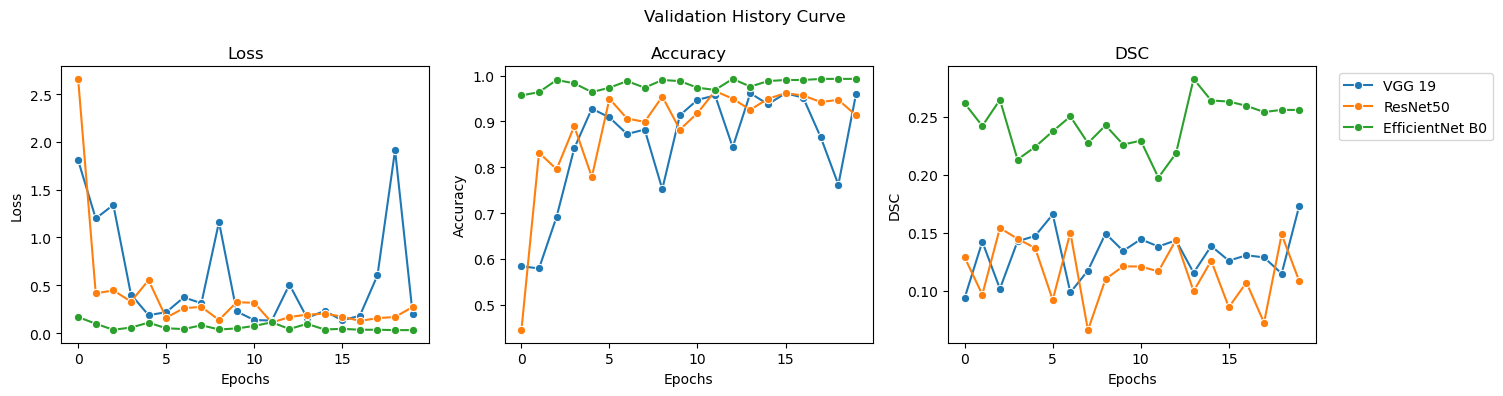

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

histories = [history_vgg,history_resnet,history_effnet]
names = ['VGG 19','ResNet50','EfficientNet B0']
plt.figure(figsize=(15,4))
for i in range(3):
    plt.subplot(1,3,1)
    sns.lineplot(x=np.arange(EPOCHS),y=histories[i]['val_loss'],marker='o')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')

    plt.subplot(1,3,2)
    sns.lineplot(x=np.arange(EPOCHS),y=histories[i]['val_acc'],marker='o')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')

    plt.subplot(1,3,3)
    sns.lineplot(x=np.arange(EPOCHS),y=histories[i]['val_dsc'],marker='o',label=names[i])
    plt.legend(loc='upper right',bbox_to_anchor=(1.5,1))
    plt.title('DSC')
    plt.xlabel('Epochs')
    plt.ylabel('DSC')
plt.suptitle('Validation History Curve')
plt.tight_layout()
plt.show()

In [72]:
results = evaluate(MODEL_RESNET,test_dl)
(acc,dsc,iou) = results['metrics']
(Xs,ys,y_preds,Ms,cams) = results['data']
M_bbox,cam_bbox = results['bbox']
print(acc,dsc,iou)

0.9116279069767442 tensor(0.0003) tensor(0.1037)


In [73]:
results = evaluate(MODEL_VGG,test_dl)
(acc,dsc,iou) = results['metrics']
(Xs,ys,y_preds,Ms,cams) = results['data']
M_bbox,cam_bbox = results['bbox']
print(acc,dsc,iou)

0.9395348837209302 tensor(0.0861) tensor(0.1486)


In [74]:
results = evaluate(MODEL_EFFNET,test_dl)
(acc,dsc,iou) = results['metrics']
(Xs,ys,y_preds,Ms,cams) = results['data']
M_bbox,cam_bbox = results['bbox']
print(acc,dsc,iou)

0.9953488372093023 tensor(0.1532) tensor(0.2038)


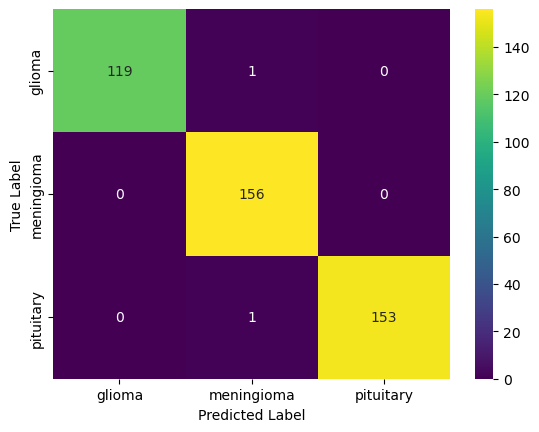

In [110]:
plot_confmat(ys,y_preds,classes=loader.classes)

TypeError: unhashable type: 'list'